In [2]:
%matplotlib ipympl

import importlib
import detect_peaks_refactor as peaks
import peak_detection.data_io as data_io
import os

importlib.reload(data_io)
importlib.reload(peaks)

#apt_file = 'APT_test\\R13_40310Zr Unsaved - Top Level ROI.csv'
apt_file = 'APT_test\\R13_40310Zr Unsaved - Top Level ROI.apt'
rrng_file = 'RRNG_test\\R13_40310Zr Top Level ROI.RRNG'
output_dir = os.path.join(os.getcwd(), 'gg2')
#result = peaks.process_dataset(apt_file, rrng_file, output_dir='gg2', flag_unknowns=True)
# TODO: Consider changing default training path to what's specified here
training_path='peak_detection/Ionclassifier/training_data/NewData_peakshift0_noise0_newchg/Data0001'
result = peaks.process_dataset(apt_file, rrng_file, output_dir='gg2', flag_unknowns=True, save_rrng_output=True, mc_threshold=0.2
                               , training_path=training_path, use_neighborhood=False, use_signature=False, unknown_molecule_rf=True, unknown_molecule_rf_threshold=0.1
                               , training_num_files=5000, augment_molecule_training_charge_ratios=True)



Detecting peaks for gg2 (Zoom: None)...
  Metadata saved: gg2/gg2_rf_elements.txt, gg2/gg2_true_species.txt
Start inference
Speed:  46.1ms inference, 4.0ms postprocess for per spectrum 
Training RF model on base elements: ['Al', 'C', 'Co', 'Cu', 'Ga', 'H', 'Ni', 'Ti', 'Zr']
Target classes for model (9): Al, C, Co, Cu, Ga, H, Ni, Ti, Zr


Loading and parsing classifier training data: 100%|██████████| 5000/5000 [00:10<00:00, 474.82it/s]


Loaded training data with feature vector length: 1 (Neighborhood: 1, Signature: 0)
  Building mc-distance lookup table...
  Molecule-only RF target classes (2): H2, HZr


Loading and parsing classifier training data: 100%|██████████| 5000/5000 [00:10<00:00, 473.99it/s]


Loaded training data with feature vector length: 1 (Neighborhood: 1, Signature: 0)
  Molecule RF recovered 4/5 unknown peaks.
  Unknown peak error report saved: gg2\gg2_unknown_peak_error_report.csv (1 rows)
  RF Accuracy (All species): 87.9% (29/33) including unknowns, 87.9% (29/33) excluding unknowns
  RF Accuracy (Elemental only): 89.3% (25/28) including unknowns, 89.3% (25/28) excluding unknowns
  Total Combined Metrics: Precision=0.943, Recall=1.000, F1=0.971
Ranges saved to gg2\gg2_peak_ranges.txt
Predicted RRNG saved to gg2\gg2_predicted.RRNG
Manual RRNG ranges: 34
Saved comparison plot to gg2\gg2_yolo_1d_model_comparison.png
Saved comparison plot to gg2\gg2_yolo_1d_model_comparison_zoom_0_25.png
Saved comparison plot to gg2\gg2_yolo_1d_model_comparison_zoom_25_50.png
Saved comparison plot to gg2\gg2_yolo_1d_model_comparison_zoom_50_75.png
Saved comparison plot to gg2\gg2_yolo_1d_model_comparison_zoom_75_100.png


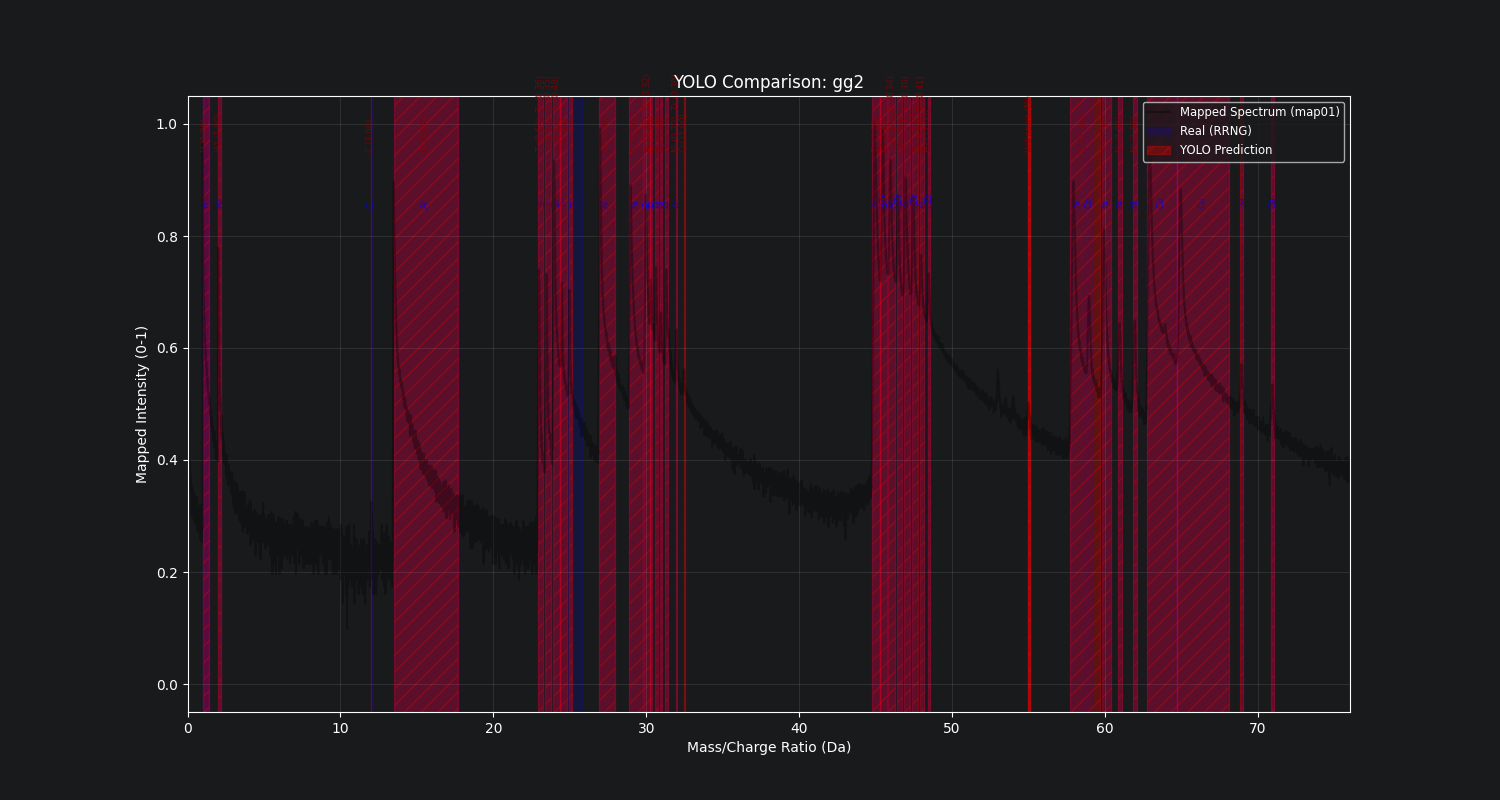

In [3]:
peaks.plot_yolo_comparison(result)

In [4]:
data_io.save_rrng(os.path.join(output_dir, 'rrng_test.rrng'), result["detected_ranges"])

woohoo!


In [2]:

result['detected_ranges']

[{'pos': 55.0301171875,
  'start': 54.95884765625,
  'end': 55.10138671875,
  'label': 'Unknown (Co)',
  'id_score': 1.0,
  'method': 'RF (Filtered)',
  'detailed_id': {'el1': 'Unknown', 'conf1': 1.0, 'el2': '', 'conf2': 0.0}},
 {'pos': 11.9943994140625,
  'start': 11.97390625,
  'end': 12.014892578125,
  'label': 'C (0.48), H (0.24)',
  'id_score': 0.48,
  'method': 'RF',
  'detailed_id': {'el1': 'C', 'conf1': 0.48, 'el2': 'H', 'conf2': 0.24}},
 {'pos': 25.0281005859375,
  'start': 24.917138671875,
  'end': 25.1390625,
  'label': 'Ti (0.76), Zr (0.16)',
  'id_score': 0.76,
  'method': 'RF',
  'detailed_id': {'el1': 'Ti', 'conf1': 0.76, 'el2': 'Zr', 'conf2': 0.16}},
 {'pos': 60.0769384765625,
  'start': 59.774121093750004,
  'end': 60.379755859375,
  'label': 'Unknown (Ni)',
  'id_score': 1.0,
  'method': 'RF (Filtered)',
  'detailed_id': {'el1': 'Unknown', 'conf1': 1.0, 'el2': '', 'conf2': 0.0}},
 {'pos': 31.3109521484375,
  'start': 31.2311669921875,
  'end': 31.3907373046875,
  'lab